# 2D Resonance Imaging with PLEIADES

This notebook demonstrates the complete 2D imaging pipeline for
spatially-resolved neutron resonance analysis. Each pixel of a
hyperspectral neutron transmission image is fitted independently using
SAMMY, and the results are aggregated into isotope abundance maps.

## Pipeline Overview

```
TIFF data  →  HyperspectralLoader  →  pixel spectra
                                           ↓
                              BatchFittingOrchestrator (parallel SAMMY)
                                           ↓
                                   ResultsAggregator  →  2D maps
                                           ↓
                          AbundanceMapGenerator + AbundanceMapVisualizer
```

**Two usage levels:**
1. **High-level**: `analyze_imaging()` — single function call for the entire pipeline
2. **Component-level**: Step-by-step control over each stage

### Two-Pass Fitting Strategy

When `fit_abundances=True` (the default), each pixel is fitted using a
transparent two-pass SAMMY strategy:

1. **Pass 1 (JSON mode)**: SAMMY reads the JSON config + ENDF files,
   generates internal parameter files, and fits global parameters
   (thickness, normalization) with fixed per-isotope abundances.
2. **Pass 2 (traditional mode)**: The generated parameter file is
   modified to enable per-isotope abundance variation (Card-10
   IFLISO=1), then SAMMY re-runs to fit abundances.

This produces spatially-varying abundance maps that reveal sample
composition across the image.

### Test Data

The LANL-ORNL example TIFF contains a synthetic two-isotope sample:
- **Ta-181** (tantalum) — dominant resonances at 97, 105, 127, 136 eV
- **U-235** (uranium) — characteristic resonances at 53, 71, 73, 161 eV

The energy axis spans 13–343 eV and was reverse-engineered from the
resonance fingerprint (see Section 2).

### Requirements

- **SAMMY executable** installed and on PATH (or provide full path)
- Test TIFF stack at `tests/data/pleiades_data/LANL-ORNL_example.tif`

In [1]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pleiades.imaging import (
    HyperspectralLoader,
    ResultsAggregator,
    AbundanceMapGenerator,
    AbundanceMapVisualizer,
    Imaging2DResults,
    analyze_imaging,
)
from pleiades.imaging.config import ImagingConfig
from pleiades.imaging.orchestrator import BatchFittingOrchestrator

## 1. Locate SAMMY Executable

The 2D imaging pipeline requires a working SAMMY installation. On ORNL systems
it is typically at `/SNS/software/sammy/bin/sammy`.

In [2]:
# Try to find SAMMY on PATH
sammy_path_str = "/Users/8cz/code-int.ornl.gov/sammy/build/bin/sammy"

sammy_executable = Path(sammy_path_str)
print(f"SAMMY executable: {sammy_executable}")

SAMMY executable: /Users/8cz/code-int.ornl.gov/sammy/build/bin/sammy


## 2. Load Hyperspectral Data

The `HyperspectralLoader` reads multi-page TIFF files where each page is one
energy bin and the 2D spatial dimensions form the image.

In [3]:
tiff_path = Path("../../tests/data/pleiades_data/LANL-ORNL_example.tif")

# Energy axis for the LANL-ORNL test data.
# Reverse-engineered by matching observed resonance dip positions (bin indices)
# to known Ta-181 ENDF resonance energies. Linear fit through 16 matched pairs
# gives E(eV) = 0.6613 * bin + 13.005 with R^2 = 0.99998.
energy = np.linspace(13.0, 343.0, 500)

loader = HyperspectralLoader(tiff_path, energy=energy)
hyperspectral = loader.load()

n_energy, height, width = hyperspectral.shape
print(f"Image shape: {height}x{width} pixels, {n_energy} energy bins")
print(f"Total pixels: {hyperspectral.n_pixels:,}")
print(f"Energy range: {energy[0]:.1f} - {energy[-1]:.1f} eV")

2026-02-18 13:48:24 | INFO     | pleiades.imaging.loader:_load_single_tiff:237 - Loading multi-page TIFF: ../../tests/data/pleiades_data/LANL-ORNL_example.tif
2026-02-18 13:48:24 | DEBUG    | pleiades.imaging.loader:load:202 - Loaded data: 500 frames × 256×256 pixels, dtype=float32
2026-02-18 13:48:25 | INFO     | pleiades.imaging.loader:load:228 - Loaded hyperspectral data: (500, 256, 256)


Image shape: 256x256 pixels, 500 energy bins
Total pixels: 65,536
Energy range: 13.0 - 343.0 eV


### Visualize the raw data

Look at the spatial image at a single energy bin, and a single pixel’s
transmission spectrum.

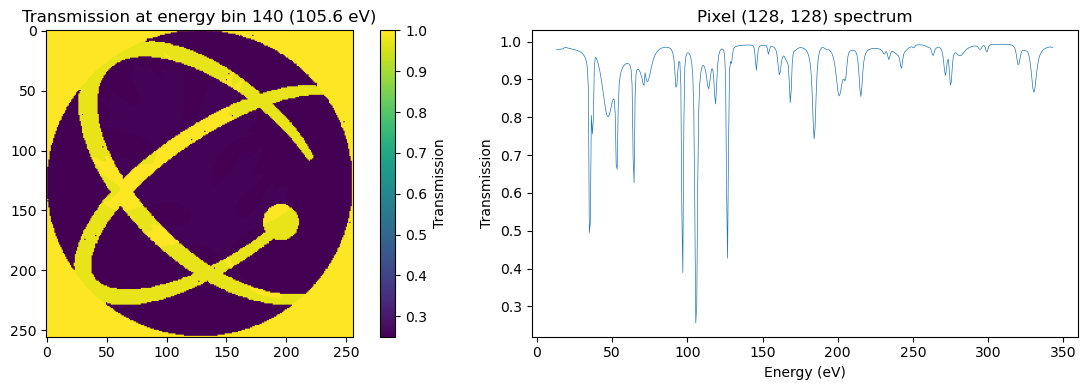

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Spatial image at a selected energy bin
bin_idx = 140
im = axes[0].imshow(hyperspectral.data[bin_idx], cmap="viridis", origin="upper")
axes[0].set_title(f"Transmission at energy bin {bin_idx} ({energy[bin_idx]:.1f} eV)")
fig.colorbar(im, ax=axes[0], label="Transmission")

# Spectrum for center pixel
center_row, center_col = height // 2, width // 2
spectrum = hyperspectral.data[:, center_row, center_col]
axes[1].plot(energy, spectrum, linewidth=0.5)
axes[1].set_xlabel("Energy (eV)")
axes[1].set_ylabel("Transmission")
axes[1].set_title(f"Pixel ({center_row}, {center_col}) spectrum")

fig.tight_layout()
plt.show()

## 3. Configure Material and Isotopes

`ImagingConfig` holds the isotope list, material properties, and energy range
for the SAMMY fitting engine. This is the same configuration used for every
pixel in the image.

The LANL-ORNL test data contains a **Ta-181 + U-235** alloy. We use custom
abundances as starting guesses (50/50) — SAMMY will optimize the actual
abundance ratio during the second fitting pass (`fit_abundances=True`).

Setting `fit_abundances=False` disables the second pass and holds
abundances fixed, fitting only the global thickness.

In [5]:
config = ImagingConfig(
    isotopes=["Ta-181", "U-235"],
    element="Ta",           # primary element for SAMMY Card Set 2
    mass_number=181,        # primary isotope mass number
    density_g_cm3=16.65,    # approximate alloy density
    thickness_mm=0.025,     # ~25 um; thin enough to avoid saturated resonances
    atomic_mass_amu=180.94788,
    natural_abundances=False,
    custom_abundances=[0.5, 0.5],  # starting guess; SAMMY will optimize
    min_energy_eV=13.0,
    max_energy_eV=343.0,
    temperature_K=293.6,
    fit_abundances=True,    # enable two-pass fitting for per-isotope abundances
)

print(f"Isotopes: {config.isotopes}")
print(f"Material: {config.element}-{config.mass_number}")
print(f"  Density: {config.density_g_cm3} g/cm\u00b3")
print(f"  Thickness: {config.thickness_mm} mm")
print(f"Energy range: {config.min_energy_eV}-{config.max_energy_eV} eV")
print(f"Abundances (starting): {config.get_abundances()}")
print(f"Fit abundances: {config.fit_abundances}")

Isotopes: ['Ta-181', 'U-235']
Material: Ta-181
  Density: 16.65 g/cm³
  Thickness: 0.025 mm
Energy range: 13.0-343.0 eV
Abundances (starting): [0.5, 0.5]
Fit abundances: True


## 4. Batch Pixel Fitting with SAMMY

The `BatchFittingOrchestrator` is the core of the 2D imaging pipeline. For
each pixel it:

1. Exports the pixel spectrum to CSV
2. Converts CSV → SAMMY `.twenty` format
3. Creates a SAMMY input file (`.inp`) from the `ImagingConfig`
4. Stages the JSON config + ENDF resonance parameter files
5. Executes SAMMY via `LocalSammyRunner` (two passes when `fit_abundances=True`)
6. Parses the `SAMMY.LPT` output for fitted abundances and χ²

When `fit_abundances=True`, each pixel runs through:
- **Pass 1**: JSON mode → fits thickness with fixed abundances
- **Pass 2**: Traditional mode with IFLISO=1 → fits per-isotope abundances

All of this runs **in parallel** across `n_workers` processes via
`ProcessPoolExecutor`. The bottleneck is SAMMY execution itself: each
two-pass fit takes ~65 s. Increasing `n_workers` scales throughput
linearly up to your CPU core count.

We start with a small 4×4 ROI (16 pixels) to verify the pipeline. A
full-image run follows in Section 8.

In [6]:
# Extract a small ROI for demonstration
roi = (120, 120, 124, 124)  # (x1, y1, x2, y2) → 4×4 = 16 pixels
pixels = list(loader.iter_pixels(roi=roi))

print(f"ROI pixels: {len(pixels)}")
print(f"Pixel grid: rows {pixels[0].row}–{pixels[-1].row}, cols {pixels[0].col}–{pixels[-1].col}")
print(f"Energy points per pixel: {len(pixels[0].energy)}")

2026-02-18 13:48:30 | INFO     | pleiades.imaging.loader:iter_pixels:370 - Iterating pixels in ROI: x=[120,124), y=[120,124)


ROI pixels: 16
Pixel grid: rows 120–123, cols 120–123
Energy points per pixel: 500


In [ ]:
import os

N_WORKERS = min(8, os.cpu_count() or 4)
print(f"Using {N_WORKERS} parallel workers (CPU cores: {os.cpu_count()})")

# Create the orchestrator
orchestrator = BatchFittingOrchestrator(
    imaging_config=config,
    sammy_executable=sammy_executable,
    n_workers=N_WORKERS,
)

# Fit all pixels in the ROI
# Each pixel gets its own SAMMY execution with isolated temp files
# Two-pass fitting (~65s/pixel) is enabled via config.fit_abundances=True
pixel_results = orchestrator.fit_pixels(
    pixels,
    timeout_per_job=120.0,  # seconds per pixel (two-pass needs more time)
    max_retries=1,          # retry failed pixels once
)

# Summarize results
n_success = sum(1 for r in pixel_results if r.success)
n_failed = len(pixel_results) - n_success
print(f"\nResults: {n_success} succeeded, {n_failed} failed out of {len(pixel_results)} pixels")

### Inspect individual pixel results

Each `PixelFitResult` contains the fitted nuclear parameters (isotope
abundances), chi-squared goodness of fit, and success/failure status.

In [8]:
for result in pixel_results[:4]:  # show first 4
    status = "✓" if result.success else "✗"
    chi_str = f"{result.chi_squared:.2f}" if result.chi_squared else "N/A"
    print(f"  Pixel ({result.row}, {result.col}): {status}  χ²={chi_str}", end="")
    if result.success and result.fit_results:
        abundances = result.get_abundances()
        print(f"  abundances={[f'{a:.4f}' for a in abundances]}")
    elif result.error_message:
        print(f"  error: {result.error_message[:80]}")
    else:
        print()

  Pixel (120, 120): ✓  χ²=25377.10  abundances=['0.4533', '0.8658']
  Pixel (120, 121): ✓  χ²=25377.10  abundances=['0.4533', '0.8658']
  Pixel (120, 122): ✓  χ²=25377.10  abundances=['0.4533', '0.8658']
  Pixel (120, 123): ✓  χ²=25377.10  abundances=['0.4533', '0.8658']


## 5. Aggregate Results into 2D Maps

The `ResultsAggregator` takes the list of per-pixel fit results and
builds 2D abundance maps, a chi-squared map, and a boolean success mask.

Since we only fitted a small ROI, we aggregate over the full image dimensions
(unfitted pixels will be NaN).

In [9]:
aggregator = ResultsAggregator(
    isotope_names=config.isotopes,
    height=height,
    width=width,
)
results = aggregator.aggregate(pixel_results, hyperspectral)

print(f"Abundance maps shape: {results.abundance_maps.shape}  (n_isotopes, height, width)")
print(f"Chi-squared map shape: {results.chi_squared_map.shape}")
print(f"Fitted pixels: {results.success_mask.sum()} / {results.success_mask.size}")
print(f"Isotopes: {results.isotope_names}")

2026-02-18 13:55:40 | INFO     | pleiades.imaging.aggregator:aggregate:125 - Aggregated 16 pixel results: 16 succeeded, 65520 failed/missing


Abundance maps shape: (2, 256, 256)  (n_isotopes, height, width)
Chi-squared map shape: (256, 256)
Fitted pixels: 16 / 65536
Isotopes: ['Ta-181', 'U-235']


## 6. Visualize Abundance Maps

`AbundanceMapGenerator` extracts individual isotope maps.
`AbundanceMapVisualizer` provides publication-quality plots.

In [10]:
gen = AbundanceMapGenerator(results)

for isotope in config.isotopes:
    iso_map = gen.generate_map(isotope)
    # Show just the ROI region where we have real data
    roi_slice = iso_map[120:124, 120:124]
    print(f"{isotope} abundance in ROI:")
    print(np.array2string(roi_slice, precision=4, suppress_small=True))
    print()

# Quality map
chi2_map = gen.generate_quality_map("chi_squared")
roi_chi2 = chi2_map[120:124, 120:124]
print(f"Chi-squared in ROI:")
print(np.array2string(roi_chi2, precision=2, suppress_small=True))

Ta-181 abundance in ROI:
[[0.4533 0.4533 0.4533 0.4533]
 [0.4533 0.4533 0.4533 0.4533]
 [0.4533 0.4533 0.4533 0.4533]
 [0.4533 0.4533 0.4533 0.4533]]

U-235 abundance in ROI:
[[0.8658 0.8658 0.8658 0.8658]
 [0.8658 0.8658 0.8658 0.8658]
 [0.8658 0.8658 0.8658 0.8658]
 [0.8658 0.8658 0.8658 0.8658]]

Chi-squared in ROI:
[[25377.1 25377.1 25377.1 25377.1]
 [25377.1 25377.1 25377.1 25377.1]
 [25377.1 25377.1 25377.1 25377.1]
 [25377.1 25377.1 25377.1 25377.1]]


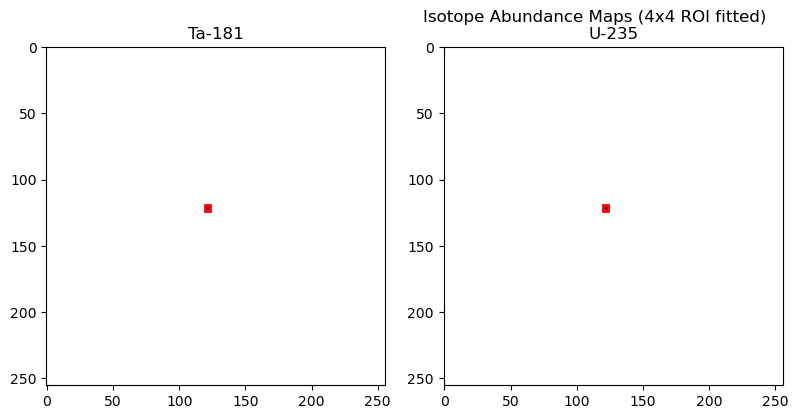

In [11]:
viz = AbundanceMapVisualizer(results)

# Plot all isotopes side by side
fig, axes = viz.plot_multi_isotope(config.isotopes)
fig.suptitle("Isotope Abundance Maps (4x4 ROI fitted)", y=1.02)

# Highlight the ROI on each subplot
from matplotlib.patches import Rectangle
for ax in axes.flat:
    if ax.get_visible():
        rect = Rectangle((119.5, 119.5), 4, 4, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
plt.show()

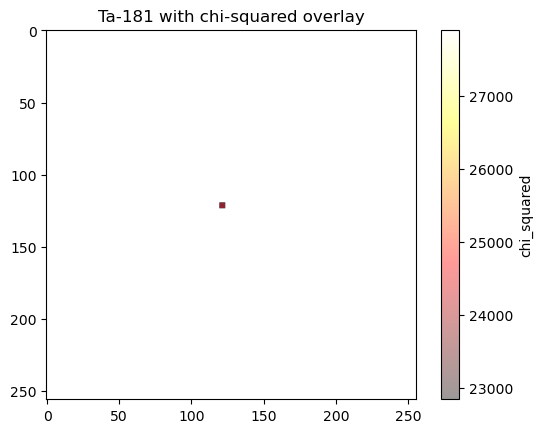

In [12]:
# Quality overlay: chi-squared on top of Ta-181 abundance
fig, ax = viz.plot_quality_overlay("Ta-181", quality_metric="chi_squared", alpha=0.4)
ax.set_title("Ta-181 with chi-squared overlay")
plt.show()

## 7. Save and Reload Results

Results persist to HDF5 for later visualization or further analysis.

In [13]:
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    h5_path = Path(tmpdir) / "imaging_results.h5"
    results.save_hdf5(h5_path)
    print(f"Saved to {h5_path.name} ({h5_path.stat().st_size / 1024:.0f} KB)")

    # Reload
    loaded = Imaging2DResults.load_hdf5(h5_path, source_hyperspectral=hyperspectral)
    print(f"Loaded isotopes: {loaded.isotope_names}")
    print(f"Maps shape: {loaded.abundance_maps.shape}")

    # Verify round-trip fidelity
    np.testing.assert_array_equal(results.abundance_maps, loaded.abundance_maps)
    print("Round-trip verification: PASSED")

Saved to imaging_results.h5 (25 KB)
Loaded isotopes: ['Ta-181', 'U-235']
Maps shape: (2, 256, 256)
Round-trip verification: PASSED


## 8. Full-Image Isotope Mapping with `analyze_imaging()`

The entire pipeline collapses into a single `analyze_imaging()` call.
Here we fit the **full 256×256 image** using spatial `stride` to reduce
the number of pixels while preserving spatial coverage.

The LANL-ORNL test data encodes two overlapping logos — one per
isotope — that should appear as distinct patterns in the abundance maps:
- **ORNL logo** (atom/orbital symbol) — one isotope composition
- **LANL logo** (oak leaf) — different isotope composition

### Stride parameter

`stride=N` fits every Nth pixel in both row and column directions.
Unfitted pixels remain NaN in the output maps.

| Stride | Grid | Pixels | Est. time (8 workers) |
|--------|------|--------|----------------------|
| 4 | 64×64 | 4,096 | ~9 h |
| 8 | 32×32 | 1,024 | ~2.5 h |
| 16 | 16×16 | 256 | ~35 min |

Adjust `STRIDE` below based on your available time.

In [ ]:
import time

STRIDE = 8  # 32×32 grid; change to 16 for faster (~35 min) or 4 for sharper (~9 h)

n_pixels_est = (256 // STRIDE) ** 2
print(f"Fitting full image with stride={STRIDE}: ~{n_pixels_est} pixels")
print(f"Estimated time with {N_WORKERS} workers: ~{n_pixels_est * 70 / N_WORKERS / 60:.0f} min")

t0 = time.time()
results_full = analyze_imaging(
    source=tiff_path,
    imaging_config=config,
    sammy_executable=sammy_executable,
    energy=energy,
    n_workers=N_WORKERS,
    stride=STRIDE,
    timeout_per_job=120.0,
    max_retries=1,
)
elapsed = time.time() - t0

n_fitted = results_full.success_mask.sum()
print(f"\nCompleted in {elapsed/60:.1f} min")
print(f"Success rate: {n_fitted} / {n_pixels_est} pixels")
print(f"Effective rate: {elapsed/max(n_fitted,1):.1f} s/pixel ({n_fitted/elapsed*60:.1f} px/min)")

In [ ]:
# Visualize the full-image abundance maps
viz_full = AbundanceMapVisualizer(results_full)
fig, axes = viz_full.plot_multi_isotope(config.isotopes)
fig.suptitle(f"Isotope Abundance Maps (full image, stride={STRIDE})", y=1.02)
plt.show()

### `analyze_imaging()` parameter reference

| Parameter | Description | Default |
|-----------|-------------|---------|
| `source` | Path to TIFF file or directory | *required* |
| `imaging_config` | Isotopes and material properties | *required* |
| `sammy_executable` | Path to SAMMY binary | *required* |
| `energy` | Energy axis (eV); inferred if `None` | `None` |
| `n_workers` | Parallel SAMMY processes | `4` |
| `roi` | Sub-region `(x1, y1, x2, y2)` | `None` (all) |
| `stride` | Spatial stride (N → every Nth pixel) | `1` |
| `checkpoint_file` | Save/resume checkpoint | `None` |
| `resume` | Resume from existing checkpoint | `False` |
| `timeout_per_job` | Max seconds per pixel | `None` |
| `max_retries` | Retry failed pixels | `0` |
| `temp_manager` | Custom `TempFileManager` | auto-created |
| `save_path` | Auto-save results to HDF5 | `None` |

### `ImagingConfig.fit_abundances`

| Value | Behaviour | Typical runtime/pixel |
|-------|-----------|----------------------|
| `True` (default) | Two-pass: fits thickness then per-isotope abundances | ~65 s |
| `False` | Single-pass: fits thickness only, abundances held fixed | ~30 s |

## Summary

This notebook demonstrated the full 2D resonance imaging pipeline on a
synthetic **Ta-181 + U-235** sample with overlapping ORNL/LANL logos:

1. **Load** hyperspectral TIFF data with `HyperspectralLoader`
2. **Configure** isotopes and material properties with `ImagingConfig`
3. **Fit** each pixel with SAMMY via `BatchFittingOrchestrator`
   - Two-pass fitting (`fit_abundances=True`) optimizes per-isotope abundances
   - Pass 1: JSON mode fits global thickness; Pass 2: traditional mode fits abundances
   - Parallel execution via `ProcessPoolExecutor` (scale with `n_workers`)
4. **Aggregate** per-pixel results into 2D maps with `ResultsAggregator`
5. **Visualize** abundance and quality maps with `AbundanceMapVisualizer`
6. **Save/load** results in HDF5 format
7. **One-call API** via `analyze_imaging()` with `stride` for fast previews

### Performance tips
- Increase `n_workers` up to your CPU core count
- Use `stride` for quick previews of large images (stride=8 → 16× fewer pixels)
- Use `checkpoint_file` + `resume=True` for long runs